In [1]:
%matplotlib inline
import sys, os, json
import torch
import torch.nn as nn
import numpy as np
import torchvision
from torch.utils.data import DataLoader

sys.path.append('..')
from src.data.degredation import get_transforms
from src.models.resnet import resnet18  # CIFAR-native 32x32
from src.training.train import train, test

import matplotlib.pyplot as plt
from custom.figure import mm, color

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams['font.family'] = 'DejaVu Sans'


In [2]:
dir = "cifar10-native-gradual"
num_net = 10
output_size = 10
lr_target = 0.0001  # Adam lr for downstream real-data training

figure_dir = os.path.join("..", "figures", dir)
save_dir = os.path.join("..", "results", dir)
warmup_dir = os.path.join("..", "results", "cifar10-native-0919")  # r=10 warm-up checkpoints
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

criterion = nn.CrossEntropyLoss()
batch_size = 128

dataset_dir = "../dataset"
train_dataset = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=True, download=True,
    transform=get_transforms("cifar10", blur=0, color=1, test=False))
train_degradation_dataset = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=True, download=True,
    transform=get_transforms("cifar10", blur=7, color=0, test=False))
test_dataset = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=False, download=True,
    transform=get_transforms("cifar10", blur=0, color=1, test=True))
test_degradation_dataset = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=False, download=True,
    transform=get_transforms("cifar10", blur=7, color=0, test=True))

num_workers = 8  # CPU-bound blur transform was the bottleneck at num_workers=0 (~50s/epoch)

train_degradation_loader = DataLoader(train_degradation_dataset, batch_size=batch_size, shuffle=True,
                                       num_workers=num_workers, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, persistent_workers=True)
test_degradation_loader = DataLoader(test_degradation_dataset, batch_size=batch_size, shuffle=False,
                                      num_workers=num_workers, persistent_workers=True)

print(f"Train(degraded): {len(train_degradation_dataset)}  "
      f"Test: {len(test_dataset)}  Test(degraded): {len(test_degradation_dataset)}")


c:\Users\vslab#1\Desktop\Chaewon\critical-period\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train(degraded): 50000  Test: 10000  Test(degraded): 10000


In [3]:
def warmup_ckpt_path(net_idx, r=10):
    return os.path.join(warmup_dir, f"warmup_native_lr0.1_r{r}_{net_idx}.pth")

def ckpt_path(tag, i):
    return os.path.join(save_dir, f"best_model_{tag}_{i}.pth")

def info_path(tag, i):
    return os.path.join(save_dir, f"training_info_{tag}_{i}.json")


def run_gradual_training(tag, n_epochs, r=10, lr=lr_target, num_net=num_net):
    """Load each net's r=10 noise warm-up checkpoint
    train with degraded CIFAR-10 for n_epochs, tracking blur + clean test accuracy every epoch"""
    training_info = []

    for net_idx in range(num_net):
        model = resnet18(num_classes=output_size).to(device)

        warmup_path = warmup_ckpt_path(net_idx, r)
        assert os.path.exists(warmup_path), f"missing warm-up checkpoint: {warmup_path}"
        model.load_state_dict(torch.load(warmup_path, map_location=device))

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)
        info = dict(train_loss=[], train_acc=[], blur_test_loss=[], blur_test_acc=[],
                    clean_test_loss=[], clean_test_acc=[], best_blur_acc=0.0)

        for epoch in range(n_epochs):
            train_loss, train_acc = train(model, train_degradation_loader, optimizer, criterion, scheduler, device=device)
            blur_test_loss, blur_test_acc = test(model, test_degradation_loader, criterion, device=device)
            clean_test_loss, clean_test_acc = test(model, test_loader, criterion, device=device)

            info["train_loss"].append(train_loss); info["train_acc"].append(train_acc)
            info["blur_test_loss"].append(blur_test_loss); info["blur_test_acc"].append(blur_test_acc)
            info["clean_test_loss"].append(clean_test_loss); info["clean_test_acc"].append(clean_test_acc)

            if blur_test_acc > info["best_blur_acc"]:
                info["best_blur_acc"] = blur_test_acc
                torch.save(model.state_dict(), ckpt_path(tag, net_idx))

            print(f"[{tag}] net {net_idx} epoch {epoch+1}/{n_epochs} "
                  f"train_acc={train_acc:.4f} blur_test_acc={blur_test_acc:.4f} clean_test_acc={clean_test_acc:.4f}")

        with open(info_path(tag, net_idx), "w") as f:
            json.dump(info, f)
        training_info.append(info)

    return training_info


def run_gradual_training_chained(tag, n_epochs_list, r=10, lr=lr_target, num_net=num_net):
    """Like run_gradual_training, but trains each net CONTINUOUSLY up to
    max(n_epochs_list) instead of restarting from the warm-up checkpoint for
    every n -- avoids redoing the overlapping epoch ranges. Snapshots a
    checkpoint + training_info at every n in n_epochs_list along the way.
    Returns {n: [info_net0, info_net1, ...]}, same shape as calling
    run_gradual_training(..., n_epochs=n) once per n would have given."""
    max_epochs = max(n_epochs_list)
    n_set = set(n_epochs_list)
    sorted_n = sorted(n_set)
    full_info = []

    for net_idx in range(num_net):
        # resume from the largest already-completed snapshot for this tag, if any
        start_epoch = 0
        info = dict(train_loss=[], train_acc=[], blur_test_loss=[], blur_test_acc=[],
                    clean_test_loss=[], clean_test_acc=[])
        resumed = False
        for n in reversed(sorted_n):
            if os.path.exists(ckpt_path(f"{tag}_n{n}", net_idx)) and os.path.exists(info_path(f"{tag}_n{n}", net_idx)):
                with open(info_path(f"{tag}_n{n}", net_idx)) as f:
                    info = json.load(f)
                start_epoch = n
                resumed = True
                break

        model = resnet18(num_classes=output_size).to(device)
        if resumed:
            model.load_state_dict(torch.load(ckpt_path(f"{tag}_n{start_epoch}", net_idx), map_location=device))
            print(f"[{tag}] net {net_idx} resuming from n={start_epoch}")
        else:
            warmup_path = warmup_ckpt_path(net_idx, r)
            assert os.path.exists(warmup_path), f"missing warm-up checkpoint: {warmup_path}"
            model.load_state_dict(torch.load(warmup_path, map_location=device))

        if start_epoch >= max_epochs:
            full_info.append(info)
            continue

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

        for epoch in range(start_epoch, max_epochs):
            train_loss, train_acc = train(model, train_degradation_loader, optimizer, criterion, scheduler, device=device)
            blur_test_loss, blur_test_acc = test(model, test_degradation_loader, criterion, device=device)
            clean_test_loss, clean_test_acc = test(model, test_loader, criterion, device=device)

            info["train_loss"].append(train_loss); info["train_acc"].append(train_acc)
            info["blur_test_loss"].append(blur_test_loss); info["blur_test_acc"].append(blur_test_acc)
            info["clean_test_loss"].append(clean_test_loss); info["clean_test_acc"].append(clean_test_acc)

            n_reached = epoch + 1
            if n_reached in n_set:
                torch.save(model.state_dict(), ckpt_path(f"{tag}_n{n_reached}", net_idx))
                with open(info_path(f"{tag}_n{n_reached}", net_idx), "w") as f:
                    json.dump(info, f)

            print(f"[{tag}] net {net_idx} epoch {n_reached}/{max_epochs} "
                  f"train_acc={train_acc:.4f} blur_test_acc={blur_test_acc:.4f} clean_test_acc={clean_test_acc:.4f}")

        full_info.append(info)

    results_by_n = {}
    for n in n_epochs_list:
        results_by_n[n] = [{k: v[:n] for k, v in info.items()} for info in full_info]
    return results_by_n


## Quick test: r=5 warm-up -> 5 epochs gradual training, blur/clean accuracy + timing

Sanity check + timing benchmark before running the full sweep above. num_net=1 so it's fast.

In [4]:
import time

t0 = time.time()
test_results = run_gradual_training("gradual_r5_test", n_epochs=5, r=5, num_net=1)
elapsed = time.time() - t0

final_blur_acc = test_results[0]["blur_test_acc"][-1]
final_clean_acc = test_results[0]["clean_test_acc"][-1]

print(f"elapsed: {elapsed:.1f}s total, {elapsed/5:.1f}s/epoch (train + 2 test evals)")
print(f"final blur test acc:  {final_blur_acc:.4f}")
print(f"final clean test acc: {final_clean_acc:.4f}")

[gradual_r5_test] net 0 epoch 1/5 train_acc=0.1913 blur_test_acc=0.3129 clean_test_acc=0.2156
[gradual_r5_test] net 0 epoch 2/5 train_acc=0.3572 blur_test_acc=0.4089 clean_test_acc=0.2301
[gradual_r5_test] net 0 epoch 3/5 train_acc=0.4309 blur_test_acc=0.4686 clean_test_acc=0.2905
[gradual_r5_test] net 0 epoch 4/5 train_acc=0.4951 blur_test_acc=0.5145 clean_test_acc=0.3661
[gradual_r5_test] net 0 epoch 5/5 train_acc=0.5467 blur_test_acc=0.5472 clean_test_acc=0.4413
elapsed: 74.8s total, 15.0s/epoch (train + 2 test evals)
final blur test acc:  0.5472
final clean test acc: 0.4413


Sweep n_epochs = 5, 10, 15, ..., 50, trained continuously from the r=10 warm-up weights in one pass (chained), snapshotting at each n instead of restarting.

In [6]:
n_epochs_list = [5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]
sweep_results = run_gradual_training_chained("gradual_r10", n_epochs_list, r=10)


[gradual_r10] net 0 epoch 1/50 train_acc=0.2008 blur_test_acc=0.3354 clean_test_acc=0.2412
[gradual_r10] net 0 epoch 2/50 train_acc=0.3647 blur_test_acc=0.3884 clean_test_acc=0.2753
[gradual_r10] net 0 epoch 3/50 train_acc=0.4295 blur_test_acc=0.4439 clean_test_acc=0.3144
[gradual_r10] net 0 epoch 4/50 train_acc=0.4848 blur_test_acc=0.4989 clean_test_acc=0.3077
[gradual_r10] net 0 epoch 5/50 train_acc=0.5340 blur_test_acc=0.5610 clean_test_acc=0.3410
[gradual_r10] net 0 epoch 6/50 train_acc=0.5792 blur_test_acc=0.5982 clean_test_acc=0.3798
[gradual_r10] net 0 epoch 7/50 train_acc=0.6141 blur_test_acc=0.6125 clean_test_acc=0.4416
[gradual_r10] net 0 epoch 8/50 train_acc=0.6418 blur_test_acc=0.6317 clean_test_acc=0.4850
[gradual_r10] net 0 epoch 9/50 train_acc=0.6617 blur_test_acc=0.6575 clean_test_acc=0.4714
[gradual_r10] net 0 epoch 10/50 train_acc=0.6806 blur_test_acc=0.6711 clean_test_acc=0.4942
[gradual_r10] net 0 epoch 11/50 train_acc=0.6975 blur_test_acc=0.6830 clean_test_acc=0.51

Summary: final blur test accuracy (mean +/- std across nets) vs. number of training epochs.

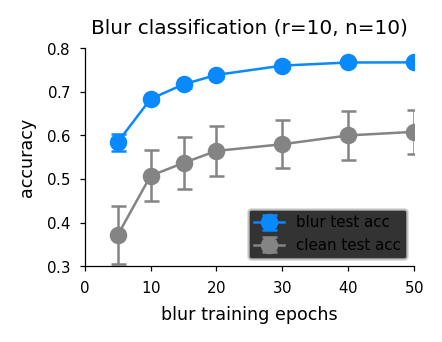

n    blur_acc    std       clean_acc   std       
5    0.5840      0.0195    0.3710      0.0665    
10   0.6833      0.0075    0.5071      0.0583    
15   0.7167      0.0075    0.5367      0.0590    
20   0.7384      0.0069    0.5642      0.0581    
30   0.7597      0.0086    0.5795      0.0547    
40   0.7668      0.0059    0.5997      0.0556    
50   0.7670      0.0063    0.6079      0.0511    


In [8]:
final_blur_acc_mean = [np.mean([info["blur_test_acc"][-1] for info in sweep_results[n]]) for n in n_epochs_list]
final_blur_acc_std = [np.std([info["blur_test_acc"][-1] for info in sweep_results[n]]) for n in n_epochs_list]
final_clean_acc_mean = [np.mean([info["clean_test_acc"][-1] for info in sweep_results[n]]) for n in n_epochs_list]
final_clean_acc_std = [np.std([info["clean_test_acc"][-1] for info in sweep_results[n]]) for n in n_epochs_list]

plt.figure(figsize=(60 * mm, 40 * mm))
plt.errorbar(n_epochs_list, final_blur_acc_mean, yerr=final_blur_acc_std,
             fmt='o-', color=color["sky"], capsize=3, label="blur test acc")
plt.errorbar(n_epochs_list, final_clean_acc_mean, yerr=final_clean_acc_std,
             fmt='o-', color=color["darkgray"], capsize=3, label="clean test acc")
plt.xlabel("blur training epochs")
plt.ylabel("accuracy")
plt.title(f"Blur classification (r=10, n=10)")
plt.legend()
plt.savefig(os.path.join(figure_dir, "blur_acc_vs_epochs.svg"))
plt.show()

print(f"{'n':<5}{'blur_acc':<12}{'std':<10}{'clean_acc':<12}{'std':<10}")
for n, bm, bs, cm, cs in zip(n_epochs_list, final_blur_acc_mean, final_blur_acc_std,
                             final_clean_acc_mean, final_clean_acc_std):
    print(f"{n:<5}{bm:<12.4f}{bs:<10.4f}{cm:<12.4f}{cs:<10.4f}")
